In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch

def load_xlstm():
    xlstm_config = AutoConfig.from_pretrained("NX-AI/xLSTM-7b")
    xlstm_config.step_kernel = "native"
    xlstm_config.chunkwise_kernel = "chunkwise--native_autograd"
    xlstm_config.sequence_kernel = "native_sequence__native"

    model = AutoModelForCausalLM.from_pretrained("NX-AI/xLSTM-7b",
                                                config=xlstm_config, device_map="auto")
    tokenizer = AutoTokenizer.from_pretrained("NX-AI/xLSTM-7b")
    
    return model, tokenizer

In [2]:
def load_mistral():
    model = AutoModelForCausalLM.from_pretrained("mistralai/Mistral-7B-v0.3", device_map="auto")
    tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.3")

    return model, tokenizer

In [3]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CORE CKA MATHEMATICS ---

def center_features(X):
    """Mean-centers the features along the batch dimension."""
    return X - X.mean(dim=0, keepdim=True)

def linear_cka(X, Y):
    """
    Computes Linear CKA between two matrices X and Y.
    X shape: (batch_size, hidden_dim_1)
    Y shape: (batch_size, hidden_dim_2)
    """
    # Center the matrices
    X_c = center_features(X)
    Y_c = center_features(Y)
    
    # Calculate the normalized dot products (Frobenius norms)
    # This is mathematically equivalent to tracing the Gram matrices, but faster.
    numerator = torch.norm(Y_c.T @ X_c) ** 2
    denominator = torch.norm(X_c.T @ X_c) * torch.norm(Y_c.T @ Y_c)
    
    return (numerator / denominator).item()

# --- 2. DATA EXTRACTION & POOLING ---

def get_layerwise_sentence_embeddings(model, tokenizer, texts, device="cuda"):
    """
    Passes texts through the model, extracts hidden states for all layers,
    and mean-pools the token dimension to create sentence embeddings.
    """
    inputs = tokenizer(texts, padding=True, return_tensors="pt").to(device)
    
    with torch.no_grad():
        # Ensure we tell the model to output the hidden states
        outputs = model(**inputs, output_hidden_states=True)
        
    # outputs.hidden_states is a tuple of (layer_0, layer_1, ..., layer_N)
    # Each layer has shape: (batch_size, sequence_length, hidden_dim)
    hidden_states = outputs.hidden_states[1:]
    
    # Create an attention mask for mean pooling (ignoring padding tokens)
    mask = inputs.attention_mask.unsqueeze(-1).float()
    
    layer_embeddings = []
    for layer in hidden_states:
        # Multiply by mask to zero out padding tokens, sum them up, and divide by sequence length
        sum_embeddings = torch.sum(layer * mask, dim=1)
        sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
        mean_pooled = sum_embeddings / sum_mask
        
        layer_embeddings.append(mean_pooled) # Shape: (batch_size, hidden_dim)
        
    return layer_embeddings

# --- 3. THE EXECUTION PIPELINE ---

# Assuming 'mistral', 'xlstm', 'mistral_tokenizer', and 'xlstm_tokenizer' are loaded
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Define your standard corpus (batch size 'n'). 
# In a real study, this should be thousands of sentences processed in minibatches.
corpus = [
    "The architecture of neural networks dictates their reasoning capacity.",
    "Exponential gating allows for better memory retrieval.",
    "Attention is all you need, or so we thought.",
    "Matrix memory states parallelize better than scalar states."
]

print("Extracting Mistral representations...")

mistral, mistral_tokenizer = load_mistral()
if mistral_tokenizer.pad_token is None:
    mistral_tokenizer.pad_token = mistral_tokenizer.eos_token

mistral_layers = get_layerwise_sentence_embeddings(mistral, mistral_tokenizer, corpus, device)

del(mistral, mistral_tokenizer)

xlstm, xlstm_tokenizer = load_xlstm()
if xlstm_tokenizer.pad_token is None:
    xlstm_tokenizer.pad_token = xlstm_tokenizer.eos_token
xlstm_layers = get_layerwise_sentence_embeddings(xlstm, xlstm_tokenizer, corpus, device)

Extracting Mistral representations...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


Computing CKA across 32 Mistral layers and 32 xLSTM layers...


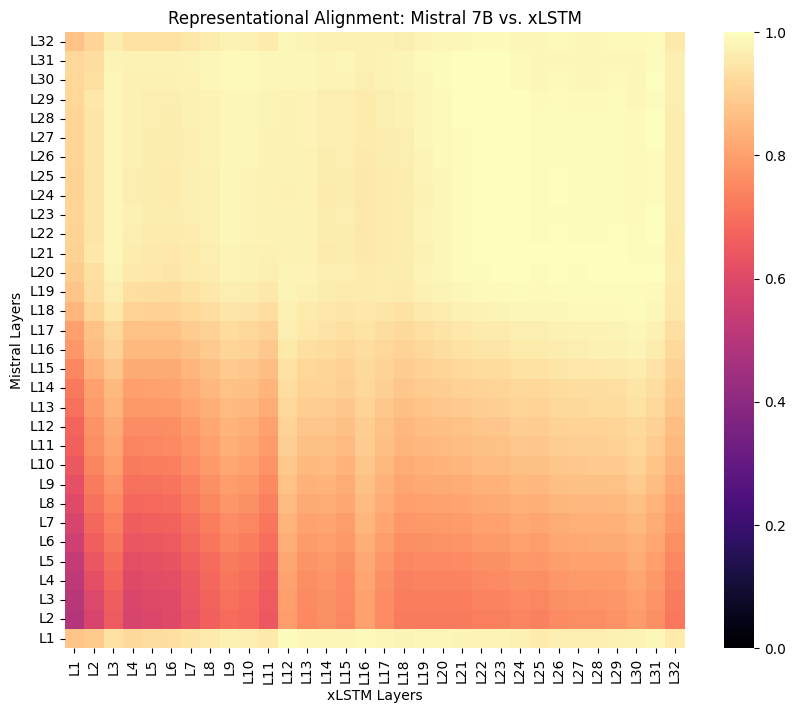

In [5]:
# 2. Initialize the CKA Heatmap Matrix
num_mistral_layers = len(mistral_layers)
num_xlstm_layers = len(xlstm_layers)
cka_matrix = np.zeros((num_mistral_layers, num_xlstm_layers))

print(f"Computing CKA across {num_mistral_layers} Mistral layers and {num_xlstm_layers} xLSTM layers...")

# 3. Compute CKA for every layer combination
for i in range(num_mistral_layers):
    for j in range(num_xlstm_layers):
        cka_score = linear_cka(mistral_layers[i], xlstm_layers[j])
        cka_matrix[i, j] = cka_score

# --- 4. VISUALIZATION ---

# Create the labels (e.g., L1, L2, L3...)
mistral_labels = [f"L{i}" for i in range(1, num_mistral_layers + 1)]
xlstm_labels = [f"L{i}" for i in range(1, num_xlstm_layers + 1)]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cka_matrix,
    cmap="magma",
    vmin=0,
    vmax=1,
    xticklabels=xlstm_labels,
    yticklabels=mistral_labels
)

plt.title("Representational Alignment: Mistral 7B vs. xLSTM")
plt.xlabel("xLSTM Layers")
plt.ylabel("Mistral Layers")
plt.gca().invert_yaxis()
plt.show()